<a href="https://colab.research.google.com/github/OmerShriky/Los-Angeles-Crime-Analysis/blob/main/Statistical_theory_final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pdfplumber -q
import pandas as pd
import numpy as np
import requests
import io
import pdfplumber
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error
import statsmodels.formula.api as smf
from scipy import stats
from statsmodels.stats.multitest import multipletests

In [2]:
url = 'https://data.lacity.org/api/views/2nrs-mtv8'
response = requests.get(url)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns',None)
if response.status_code == 200:
    data = response.json()['columns']
    df = pd.DataFrame(data)[['name','dataTypeName','description']]
    display(df.style.set_properties(**{'text-align': 'left'}))
else:
    print(f'Error: {response.status_code}')

,name,dataTypeName,description
0,DR_NO,text,"Division of Records Number: Official file number made up of a 2 digit year, area ID, and 5 digits"
1,Date Rptd,calendar_date,MM/DD/YYYY
2,DATE OCC,calendar_date,MM/DD/YYYY
3,TIME OCC,text,In 24 hour military time.
4,AREA,text,The LAPD has 21 Community Police Stations referred to as Geographic Areas within the department. These Geographic Areas are sequentially numbered from 1-21.
5,AREA NAME,text,"The 21 Geographic Areas or Patrol Divisions are also given a name designation that references a landmark or the surrounding community that it is responsible for. For example 77th Street Division is located at the intersection of South Broadway and 77th Street, serving neighborhoods in South Los Angeles."
6,Rpt Dist No,text,"A four-digit code that represents a sub-area within a Geographic Area. All crime records reference the ""RD"" that it occurred in for statistical comparisons. Find LAPD Reporting Districts on the LA City GeoHub at http://geohub.lacity.org/datasets/c4f83909b81d4786aa8ba8a74a4b4db1_4"
7,Part 1-2,number,
8,Crm Cd,text,Indicates the crime committed. (Same as Crime Code 1)
9,Crm Cd Desc,text,Defines the Crime Code provided.


In [3]:
url = 'https://data.lacity.org/api/views/2nrs-mtv8/rows.csv?accessType=DOWNLOAD'
response = requests.get(url, stream=True)
if response.status_code == 200:
    print(response.status_code)
    print(f"Content-Type: {response.headers.get('Content-Type')}")
else:
    print(f'Error: {response.status_code}')

200
Content-Type: text/csv; charset=utf-8


In [4]:
crime = pd.read_csv(io.StringIO(response.text))
crime

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,Mocodes,Vict Age,Vict Sex,Vict Descent,Premis Cd,Premis Desc,Weapon Used Cd,Weapon Desc,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,211507896,04/11/2021 12:00:00 AM,11/07/2020 12:00:00 AM,845,15,N Hollywood,1502,2,354,THEFT OF IDENTITY,0377,31,M,H,501.0,SINGLE FAMILY DWELLING,NaN,NaN,IC,Invest Cont,354.0,NaN,NaN,NaN,7800 BEEMAN AV,NaN,34.2124,-118.4092
1,201516622,10/21/2020 12:00:00 AM,10/18/2020 12:00:00 AM,1845,15,N Hollywood,1521,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",0416 0334 2004 1822 1414 0305 0319 0400,32,M,H,102.0,SIDEWALK,200.0,KNIFE WITH BLADE 6INCHES OR LESS,IC,Invest Cont,230.0,NaN,NaN,NaN,ATOLL AV,N GAULT,34.1993,-118.4203
2,240913563,12/10/2024 12:00:00 AM,10/30/2020 12:00:00 AM,1240,9,Van Nuys,933,2,354,THEFT OF IDENTITY,0377,30,M,W,501.0,SINGLE FAMILY DWELLING,NaN,NaN,IC,Invest Cont,354.0,NaN,NaN,NaN,14600 SYLVAN ST,NaN,34.1847,-118.4509
3,210704711,12/24/2020 12:00:00 AM,12/24/2020 12:00:00 AM,1310,7,Wilshire,782,1,331,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND OVER),0344,47,F,A,101.0,STREET,NaN,NaN,IC,Invest Cont,331.0,NaN,NaN,NaN,6000 COMEY AV,NaN,34.0339,-118.3747
4,201418201,10/03/2020 12:00:00 AM,09/29/2020 12:00:00 AM,1830,14,Pacific,1454,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),1300 0344 1606 2032,63,M,H,103.0,ALLEY,NaN,NaN,IC,Invest Cont,420.0,NaN,NaN,NaN,4700 LA VILLA MARINA,NaN,33.9813,-118.4350
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1004889,240710284,07/24/2024 12:00:00 AM,07/23/2024 12:00:00 AM,1400,7,Wilshire,788,1,510,VEHICLE - STOLEN,NaN,0,NaN,NaN,101.0,STREET,NaN,NaN,IC,Invest Cont,510.0,NaN,NaN,NaN,4000 W 23RD ST,NaN,34.0362,-118.3284
1004890,240104953,01/15/2024 12:00:00 AM,01/15/2024 12:00:00 AM,100,1,Central,101,2,745,VANDALISM - MISDEAMEANOR ($399 OR UNDER),0329 0400 0416,0,X,X,503.0,HOTEL,500.0,UNKNOWN WEAPON/OTHER WEAPON,IC,Invest Cont,745.0,NaN,NaN,NaN,1300 W SUNSET BL,NaN,34.0685,-118.2460
1004891,240410786,10/14/2024 12:00:00 AM,10/11/2024 12:00:00 AM,2330,4,Hollenbeck,421,1,341,"THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LIVESTK,PROD",0344,29,M,B,210.0,RESTAURANT/FAST FOOD,NaN,NaN,IC,Invest Cont,341.0,NaN,NaN,NaN,1700 ALBION ST,NaN,34.0675,-118.2240
1004892,240309674,04/24/2024 12:00:00 AM,04/24/2024 12:00:00 AM,1500,3,Southwest,358,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",1822 0334 0416 0445 0449 1202,70,F,W,102.0,SIDEWALK,308.0,STICK,IC,Invest Cont,230.0,NaN,NaN,NaN,FLOWER ST,JEFFERSON BL,34.0215,-118.2868


In [5]:
crime.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004894 entries, 0 to 1004893
Data columns (total 28 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   DR_NO           1004894 non-null  int64  
 1   Date Rptd       1004894 non-null  object 
 2   DATE OCC        1004894 non-null  object 
 3   TIME OCC        1004894 non-null  int64  
 4   AREA            1004894 non-null  int64  
 5   AREA NAME       1004894 non-null  object 
 6   Rpt Dist No     1004894 non-null  int64  
 7   Part 1-2        1004894 non-null  int64  
 8   Crm Cd          1004894 non-null  int64  
 9   Crm Cd Desc     1004894 non-null  object 
 10  Mocodes         853296 non-null   object 
 11  Vict Age        1004894 non-null  int64  
 12  Vict Sex        860263 non-null   object 
 13  Vict Descent    860251 non-null   object 
 14  Premis Cd       1004878 non-null  float64
 15  Premis Desc     1004306 non-null  object 
 16  Weapon Used Cd  327216 non-null   fl

In [6]:
crime.isnull().sum()

,0
DR_NO,0
Date Rptd,0
DATE OCC,0
TIME OCC,0
AREA,0
AREA NAME,0
Rpt Dist No,0
Part 1-2,0
Crm Cd,0
Crm Cd Desc,0


In [7]:
url = 'https://data.lacity.org/api/views/2nrs-mtv8/files/4591b6bf-5846-4de0-9fb0-8780a77a036c?download=true&filename=MO_CODES_Numerical_20191119.pdf'
response = requests.get(url)
response.status_code

200

In [8]:
mocodes = {}
for page in pdfplumber.open(io.BytesIO(response.content)).pages:
    pg = page.extract_text()
    pg = pg.split('\n')[3:-1]
    for code in pg:
        mocodes[code[:4]] = code[5:]
crime['Mocodes'] = crime['Mocodes'].fillna('').str.split()

def process_mo_row(code_list):
    if not isinstance(code_list, list):
        return "Unknown"
    if len(code_list) == 0:
        return "Unknown"
    descriptions = [mocodes.get(str(code), "Code Not Found") for code in code_list]
    return ", ".join(descriptions)


crime['Mocode Text'] = crime['Mocodes'].apply(process_mo_row)
# Handling dates
crime['DATE OCC'] = pd.to_datetime(crime['DATE OCC'])
crime['Date_Occured'] = pd.to_datetime(crime['DATE OCC'],format='%d/%m/%Y')

crime['Date Rptd'] = pd.to_datetime(crime['Date Rptd'])
crime['Date_Reported'] = pd.to_datetime(crime['Date Rptd'],format='%d/%m/%Y')

# Fix the Time of Occurrance column
crime['TIME OCC'] = crime['TIME OCC'].astype(str).str.zfill(4)

# Map the victim descent column to their corresponding description
ethnicity = {'A': 'Other Asian', 'B':'Black', 'C':'Chinese','D':'Cambodian','F':'Filipino', 'G':'Guamanian',
             'H':'Hispanic/Latin/Mexican','I':'American Indian/Alaskan Native','J':'Japanese' ,'K':'Korean','L':'Laotian',
             'O':'Other', 'P':'Pacific Islander','S':'Samoan', 'U':'Hawaiian','V':'Vietnamese','W':'White','X':'Unknown','Z':'Asian Indian'}
crime['Vict Descent'] = crime['Vict Descent'].map(ethnicity)

crime = crime[['DR_NO','Date_Reported','Date_Occured','TIME OCC','Crm Cd Desc','Mocode Text','Weapon Desc','Vict Descent','Vict Sex','Vict Age','Status Desc','AREA NAME','LOCATION','Cross Street','Premis Desc','LAT','LON']]

/tmp/ipykernel_57212/1620144304.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  crime['DATE OCC'] = pd.to_datetime(crime['DATE OCC'])
/tmp/ipykernel_57212/1620144304.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  crime['Date Rptd'] = pd.to_datetime(crime['Date Rptd'])


In [9]:
CRIME = crime[['DR_NO','Date_Occured']]

CRIME

,DR_NO,Date_Occured
0,211507896,2020-11-07
1,201516622,2020-10-18
2,240913563,2020-10-30
3,210704711,2020-12-24
4,201418201,2020-09-29
...,...,...
1004889,240710284,2024-07-23
1004890,240104953,2024-01-15
1004891,240410786,2024-10-11
1004892,240309674,2024-04-24


In [10]:
montly_count = pd.crosstab(index=CRIME['Date_Occured'].dt.month, columns=CRIME['Date_Occured'].dt.year).astype(int)
montly_count

Date_Occured,2020,2021,2022,2023,2024
Date_Occured,,,,,
1,18576,16636,18567,19970,18926
2,17284,15440,17750,18489,17394
3,16188,16354,19745,19214,16293
4,15706,16091,19837,18937,12946
5,17230,17020,20467,18908,9386
6,17060,17182,20273,18741,8126
7,17158,18690,20009,19935,8170
8,16902,18398,20144,20082,8324
9,15658,18386,19341,19321,8309


In [11]:


year2021 = montly_count[2020]-montly_count[2021]
year2122 = montly_count[2021]-montly_count[2022]
year2223 = montly_count[2022]-montly_count[2023]
year2324 = montly_count[2023]-montly_count[2024]

# Concentrate our columns into a Dictionary for looping
series_dict = {
    '2020-2021': year2021,
    '2021-2022': year2122,
    '2022-2023': year2223,
    '2023-2024': year2324
}

# Running Shapiro-Wilk test for every year and collecting the original p-values for every series

raw_p_values = []
series_names = list(series_dict.keys())

for name, series in series_dict.items():
    stat, p_val = stats.shapiro(series)
    raw_p_values.append(p_val)

# Applying multiple test corrections
alpha = 0.05

reject, adjusted_p_values, _, _ = multipletests(raw_p_values, alpha=alpha, method='bonferroni')

#placing our results in a dataframe
results_df = pd.DataFrame({
    'Series Name': series_names,
    'Raw p-value': raw_p_values,
    'Adjusted p-values':adjusted_p_values,
    'Reject Null (Is NOT Normal?)': reject
})

# Adding a column so it is easier to read
results_df['Conclusion'] = results_df['Reject Null (Is NOT Normal?)'].apply(
    lambda x: "Data does not distribute Normally (Reject H0)" if x
    else "Data is distributed normally (Failed to Reject H0)"
)

print(f"Normality Test with Multiple testing correction and a statistical significance level: {alpha}")

results_df[['Series Name', 'Raw p-value','Adjusted p-values','Conclusion']]

Normality Test with Multiple testing correction and a statistical significance level: 0.05


,Series Name,Raw p-value,Adjusted p-values,Conclusion
0,2020-2021,0.230339,0.921356,Data is distributed normally (Failed to Reject H0)
1,2021-2022,0.591344,1.000000,Data is distributed normally (Failed to Reject H0)
2,2022-2023,0.823733,1.000000,Data is distributed normally (Failed to Reject H0)
3,2023-2024,0.043248,0.172994,Data is distributed normally (Failed to Reject H0)


In [12]:
CRIME = CRIME.copy()

CRIME['date'] = pd.to_datetime(CRIME['Date_Occured'], dayfirst=True, errors='coerce')

CRIME['year'] = CRIME['date'].dt.year
CRIME['month'] = CRIME['date'].dt.month
CRIME['day'] = CRIME['date'].dt.day

def get_month_half(day):
    if pd.isna(day):
        return 'Unknown'
    return 'First_Half' if day <= 15 else 'Second_Half'

CRIME['half'] = CRIME['day'].apply(get_month_half)
CRIME['month_half'] = CRIME['month'].astype(str).str.zfill(2) + ' _ ' + CRIME['half']
bi_weekly_pivot = pd.crosstab(index=CRIME['month_half'], columns=CRIME['year']).fillna(0).astype(int)
bi_weekly_pivot

year,2020,2021,2022,2023,2024
month_half,,,,,
01 _ First_Half,9006,8250,9166,10223,8934
01 _ Second_Half,9570,8386,9401,9747,9992
02 _ First_Half,9070,8217,9995,10852,8739
02 _ Second_Half,8214,7223,7755,7637,8655
03 _ First_Half,8608,7888,9822,9605,8430
03 _ Second_Half,7580,8466,9923,9609,7863
04 _ First_Half,7537,8051,10557,9625,6444
04 _ Second_Half,8169,8040,9280,9312,6502
05 _ First_Half,8075,8414,10556,9287,5410


In [13]:


year2021 = bi_weekly_pivot[2020]-bi_weekly_pivot[2021]
year2122 = bi_weekly_pivot[2021]-bi_weekly_pivot[2022]
year2223 = bi_weekly_pivot[2022]-bi_weekly_pivot[2023]
year2324 = bi_weekly_pivot[2023]-bi_weekly_pivot[2024]

series_dict = {
    '2020-2021': year2021,
    '2021-2022': year2122,
    '2022-2023': year2223,
    '2023-2024': year2324
}

raw_p_values = []
series_names = list(series_dict.keys())

for name, series in series_dict.items():
    stat, p_val = stats.shapiro(series)
    raw_p_values.append(p_val)

alpha = 0.05

# Here we will take the adjusted p-value
reject, adjusted_p_values, _, _ = multipletests(raw_p_values, alpha=alpha, method='bonferroni')

results_df = pd.DataFrame({
    'Series Name': series_names,
    'Raw p-value': raw_p_values,
    'Adjusted p-value': adjusted_p_values,
    'Reject Null (Is NOT Normal?)': reject
})

# We will add a conclusion column
results_df['Conclusion'] = results_df['Reject Null (Is NOT Normal?)'].apply(
    lambda x: "Data does not distribute Normally (Reject H0)" if x
    else "Data is distributed normally (Failed to Reject H0)"
)

print(f"Normality Test with Multiple testing correction and a statistical significance level: {alpha}")
results_df[['Series Name', 'Raw p-value', 'Adjusted p-value',
            'Conclusion']]

Normality Test with Multiple testing correction and a statistical significance level: 0.05


,Series Name,Raw p-value,Adjusted p-value,Conclusion
0,2020-2021,0.205323,0.821294,Data is distributed normally (Failed to Reject H0)
1,2021-2022,0.579164,1.000000,Data is distributed normally (Failed to Reject H0)
2,2022-2023,0.882953,1.000000,Data is distributed normally (Failed to Reject H0)
3,2023-2024,0.008957,0.035829,Data does not distribute Normally (Reject H0)


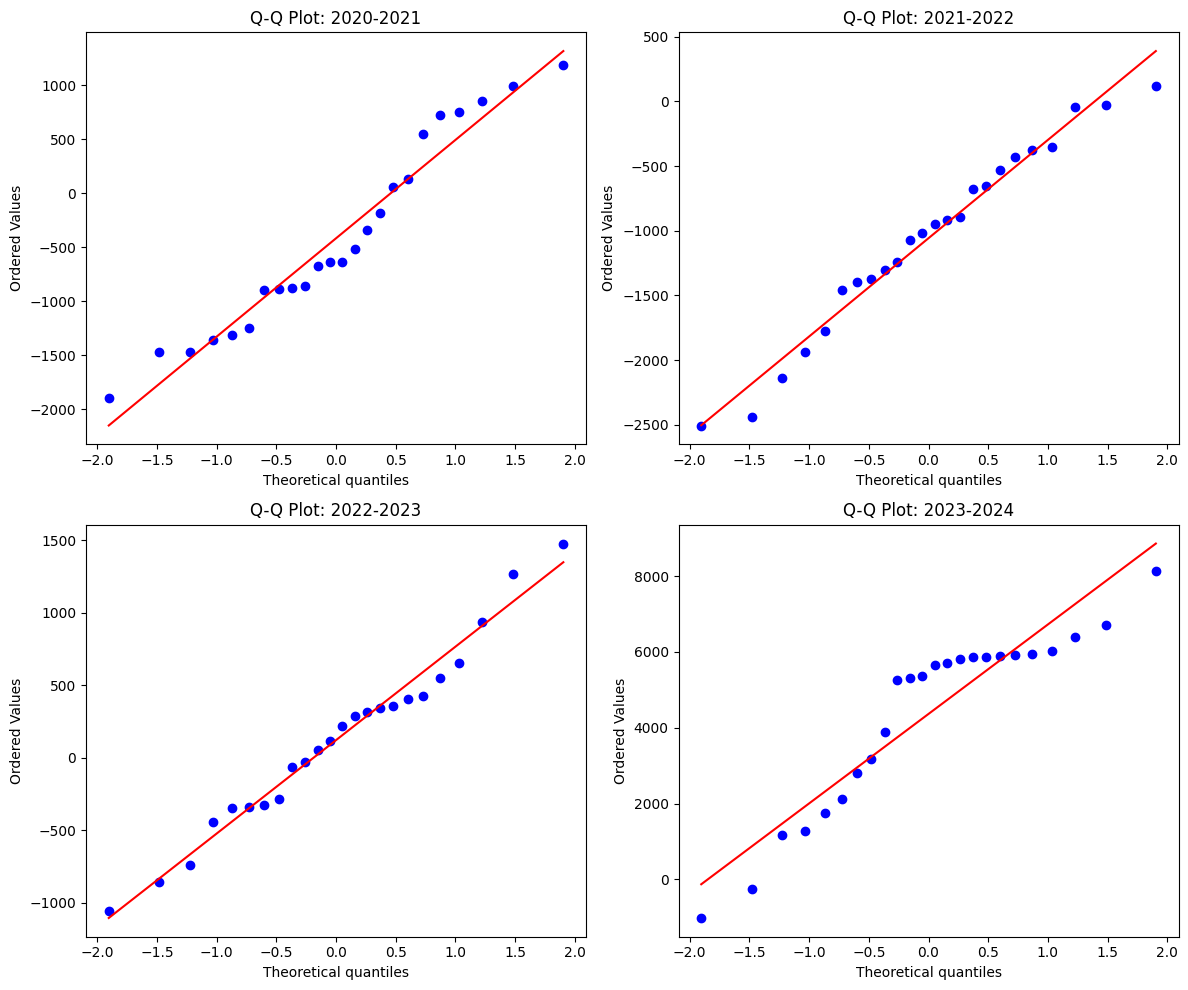

In [14]:
# Creating a Q-Q Plot
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (name, series) in enumerate(series_dict.items()):
    stats.probplot(series.dropna(), dist="norm", plot=axes[i])
    axes[i].set_title(f'Q-Q Plot: {name}')

plt.tight_layout()
plt.show()

In [15]:
# Creating a Bi-Weekly pivot Dataframe
years = bi_weekly_pivot.columns

pairs = []
raw_p_values = []

# For every two consecutive years we will run a Wilcoxon Test

for i in range(len(years) - 1):
    year_before = years[i]
    year_after = years[i+1]

    data_before = bi_weekly_pivot[year_before]
    data_after = bi_weekly_pivot[year_after]

    stat, p_val = stats.wilcoxon(data_after, data_before)

    pairs.append(f"{year_before} vs {year_after}")
    raw_p_values.append(p_val)

# Applying Bonferroni correction
reject_bonf, adj_p_bonf, _, _ = multipletests(raw_p_values, alpha=0.05, method='bonferroni')

# Applying Benjamini-Hochberg correction
reject_bh, adj_p_bh, _, _ = multipletests(raw_p_values, alpha=0.05, method='fdr_bh')

# Concentration of all the results in one DataFrame
summary_df = pd.DataFrame({
    'Comparison': pairs,
    'Raw p-value': raw_p_values,
    'Bonferroni p-val': adj_p_bonf,
    'Significant (Bonf)?': reject_bonf,
    'Benjamini-Hochberg p-val': adj_p_bh,
    'Significant (BH)?': reject_bh
})

p_cols = ['Raw p-value', 'Bonferroni p-val', 'Benjamini-Hochberg p-val']
summary_df[p_cols] = summary_df[p_cols].round(4)

print(f"Consecutive years comparison with Multiple testing correction (Alpha={alpha})")

summary_df

Consecutive years comparison with Multiple testing correction (Alpha=0.05)


,Comparison,Raw p-value,Bonferroni p-val,Significant (Bonf)?,Benjamini-Hochberg p-val,Significant (BH)?
0,2020 vs 2021,0.0370,0.148,False,0.0493,True
1,2021 vs 2022,0.0000,0.000,True,0.0000,True
2,2022 vs 2023,0.3748,1.000,False,0.3748,False
3,2023 vs 2024,0.0000,0.000,True,0.0000,True


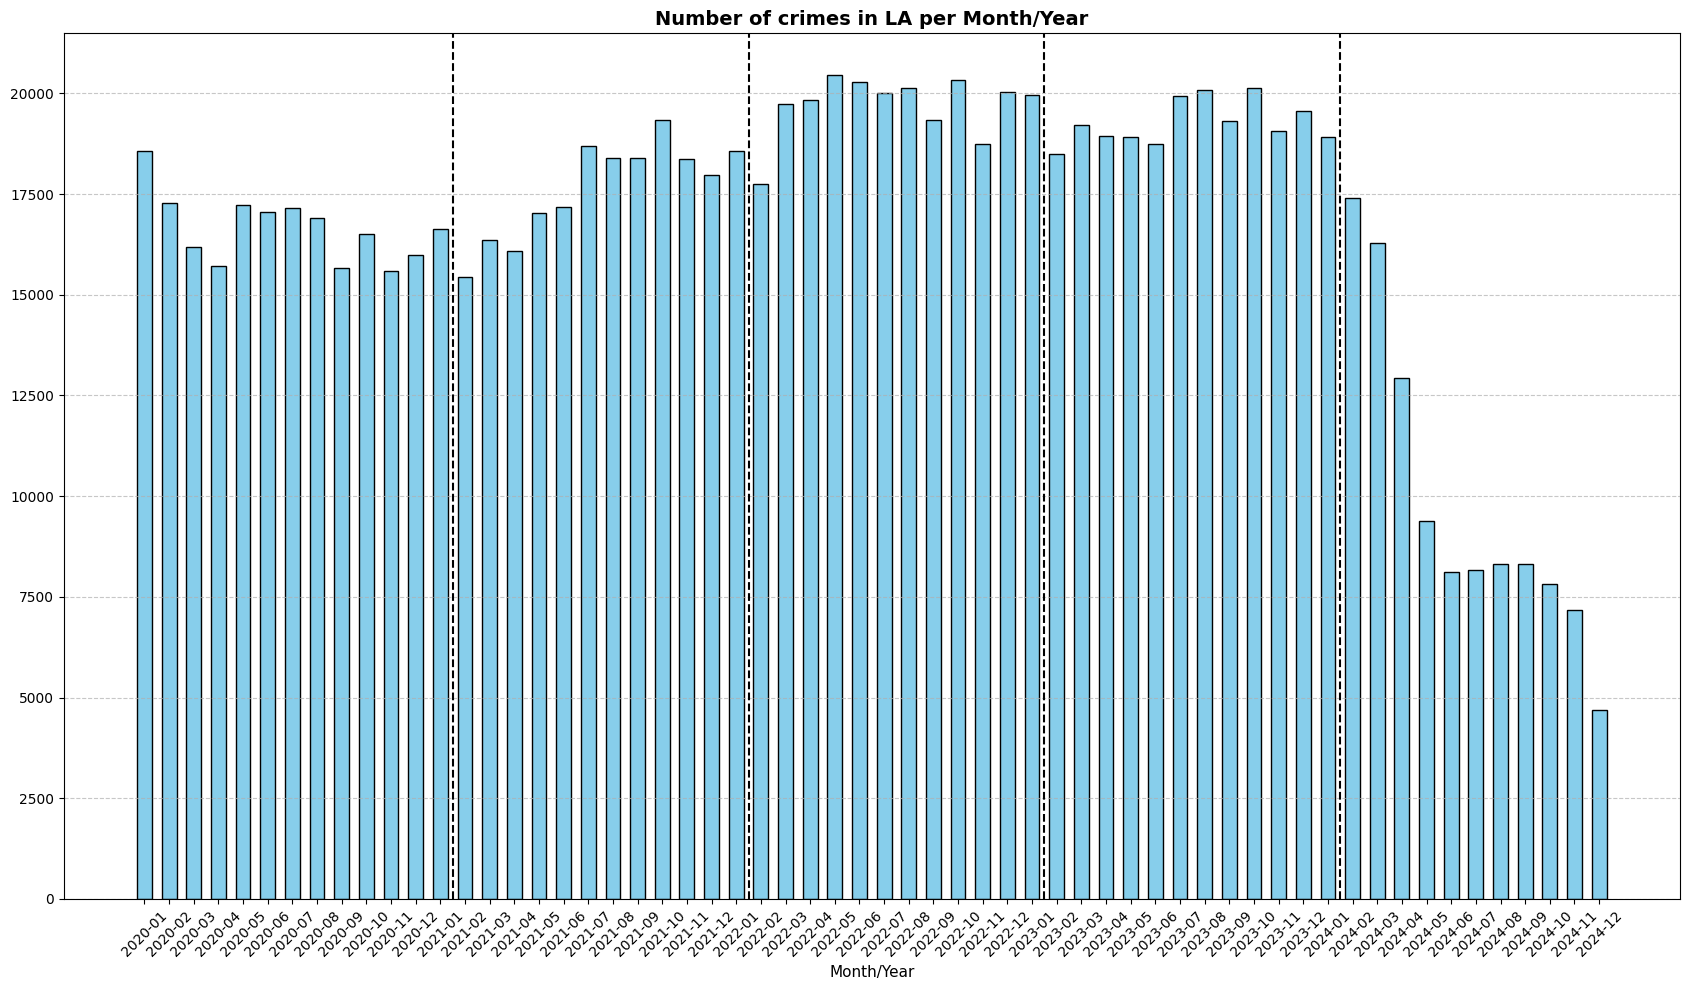

In [16]:
CRIME_month_df = CRIME.groupby(CRIME['Date_Occured'].dt.to_period('M')).size()
fig, ax = plt.subplots(figsize=(17, 10))
bars = ax.bar(CRIME_month_df.index.astype(str), CRIME_month_df.values, color='skyblue', edgecolor='black', width=0.6)
ax.set_title(f'Number of crimes in LA per Month/Year', fontsize=14, fontweight='bold')
ax.set_xlabel('Month/Year', fontsize=11)

ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)


ax.axvline(x=12.5, color='black', linestyle='--', linewidth=1.5)
ax.axvline(x=24.5, color='black', linestyle='--', linewidth=1.5)
ax.axvline(x=36.5, color='black', linestyle='--', linewidth=1.5)
ax.axvline(x=48.5, color='black', linestyle='--', linewidth=1.5)


plt.tight_layout()
plt.show()

In [17]:
violent_crime_list = ["ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT","CRM AGNST CHLD (13 OR UNDER) (14-15 & SUSP 10 YRS OLDER)","INTIMATE PARTNER - SIMPLE ASSAULT","BATTERY - SIMPLE ASSAULT","ROBBERY","CHILD ABUSE (PHYSICAL) - SIMPLE ASSAULT",
                      "CRIMINAL THREATS - NO WEAPON DISPLAYED","BATTERY WITH SEXUAL CONTACT","LETTERS, LEWD  -  TELEPHONE CALLS, LEWD","INTIMATE PARTNER - AGGRAVATED ASSAULT","ATTEMPTED ROBBERY","LEWD/LASCIVIOUS ACTS WITH CHILD","BRANDISH WEAPON",
                      "BATTERY POLICE (SIMPLE)","RAPE, ATTEMPTED","OTHER ASSAULT","SODOMY/SEXUAL CONTACT B/W PENIS OF ONE PERS TO ANUS OTH","RAPE, FORCIBLE","DISCHARGE FIREARMS/SHOTS FIRED","EXTORTION","SHOTS FIRED AT MOVING VEHICLE, TRAIN OR AIRCRAFT",
                      "ASSAULT WITH DEADLY WEAPON ON POLICE OFFICER","CHILD ANNOYING (17YRS & UNDER)","SHOTS FIRED AT INHABITED DWELLING","THROWING OBJECT AT MOVING VEHICLE","SEX,UNLAWFUL(INC MUTUAL CONSENT, PENETRATION W/ FRGN OBJ","ORAL COPULATION",
                      "SEXUAL PENETRATION W/FOREIGN OBJECT","CHILD STEALING","PURSE SNATCHING","HUMAN TRAFFICKING - COMMERCIAL SEX ACTS","KIDNAPPING","CRIMINAL HOMICIDE","LYNCHING","THREATENING PHONE CALLS/LETTERS","BOMB SCARE",
                      "CHILD ABUSE (PHYSICAL) - AGGRAVATED ASSAULT","STALKING","BATTERY ON A FIREFIGHTER","DRUGS, TO A MINOR","MANSLAUGHTER, NEGLIGENT","KIDNAPPING - GRAND ATTEMPT","FALSE IMPRISONMENT","CHILD PORNOGRAPHY",
                      "PANDERING","HUMAN TRAFFICKING - INVOLUNTARY SERVITUDE","CRUELTY TO ANIMALS","WEAPONS POSSESSION/BOMBING","LYNCHING - ATTEMPTED","PURSE SNATCHING - ATTEMPT","CHILD ABANDONMENT","BEASTIALITY, CRIME AGAINST NATURE SEXUAL ASSLT WITH ANIM",
                      "INCEST (SEXUAL ACTS BETWEEN BLOOD RELATIVES)","TRAIN WRECKING","PIMPING","CHILD NEGLECT (SEE 300 W.I.C.)","PIMPING"]

crime['Violent'] = crime['Crm Cd Desc'].isin(violent_crime_list)

/tmp/ipykernel_57212/3556854214.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  crime['Violent'] = crime['Crm Cd Desc'].isin(violent_crime_list)


In [18]:
# Get the Los Angeles Demographic data

from urllib.request import Request, urlopen

url = "https://en.wikipedia.org/wiki/Demographics_of_Los_Angeles"

req = Request(url,headers={"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"})
html = urlopen(req).read().decode("utf-8")

tables = pd.read_html(io.StringIO(html), match="Race / Ethnicity")
population = tables[0]
population = population[['Race / Ethnicity (NH = Non-Hispanic)','Pop 2020[6]']]

mix = population[population['Race / Ethnicity (NH = Non-Hispanic)'].isin(['Other race alone (NH)','Mixed race or Multiracial (NH)'])]['Pop 2020[6]'].sum(axis=0)

population = population[~population['Race / Ethnicity (NH = Non-Hispanic)'].isin(['Other race alone (NH)','Mixed race or Multiracial (NH)'])]

new_row_data = {'Race / Ethnicity (NH = Non-Hispanic)': 'other/unknown/mixed', 'Pop 2020[6]': mix}
new_row_df = pd.DataFrame([new_row_data])
population = pd.concat([population, new_row_df], ignore_index=True)

custom_order = [
    'White alone (NH)',
    'Black or African American alone (NH)',
    'Hispanic or Latino (any race)',
    'Native American or Alaska Native alone (NH)',
    'Asian alone (NH)',
    'Native Hawaiian or Pacific Islander alone (NH)',
    'other/unknown/mixed',
    'Total'
]

population['Race / Ethnicity (NH = Non-Hispanic)'] = pd.Categorical(population['Race / Ethnicity (NH = Non-Hispanic)'],categories=custom_order, ordered=True)

population = population.sort_values('Race / Ethnicity (NH = Non-Hispanic)').reset_index(drop=True)

population

,Race / Ethnicity (NH = Non-Hispanic),Pop 2020[6]
0,White alone (NH),1126052
1,Black or African American alone (NH),322553
2,Hispanic or Latino (any race),1829991
3,Native American or Alaska Native alone (NH),6614
4,Asian alone (NH),454585
5,Native Hawaiian or Pacific Islander alone (NH),4573
6,other/unknown/mixed,154379
7,Total,3898747


In [19]:
ethnicity_map = {'White': 'White alone (NH)',
 'Black': 'Black or African American alone (NH)',
 'Hispanic/Latin/Mexican': 'Hispanic or Latino (any race)',
 'American Indian/Alaskan Native': 'Native American or Alaska Native alone (NH)',
 'Asian Indian': 'Asian alone (NH)',
 'Cambodian': 'Asian alone (NH)',
 'Chinese': 'Asian alone (NH)',
 'Filipino': 'Asian alone (NH)',
 'Japanese': 'Asian alone (NH)',
 'Korean': 'Asian alone (NH)',
 'Laotian': 'Asian alone (NH)',
 'Other Asian': 'Asian alone (NH)',
 'Vietnamese': 'Asian alone (NH)',
 'Pacific Islander': 'Native Hawaiian or Pacific Islander alone (NH)',
 'Samoan': 'Native Hawaiian or Pacific Islander alone (NH)',
 'Guamanian': 'Native Hawaiian or Pacific Islander alone (NH)',
 'Hawaiian': 'Native Hawaiian or Pacific Islander alone (NH)',
 'Other': 'other/unknown/mixed',
 'Unknown': 'other/unknown/mixed'}

crime = crime.copy()

crime['Vict Ethnicity'] = crime['Vict Descent'].map(ethnicity_map)

model_df = crime.groupby([crime['Date_Occured'].dt.to_period('M'),'Vict Ethnicity'])['Date_Occured'].count()
model_df = model_df.rename('CrimeCount')
model_df = model_df.reset_index(inplace=False)
model_df['Year'] = model_df['Date_Occured'].dt.year
model_df['Month'] = model_df['Date_Occured'].dt.month
model_df = pd.merge(model_df, population, left_on='Vict Ethnicity', right_on='Race / Ethnicity (NH = Non-Hispanic)', how='left')

model_df = model_df[['Date_Occured','Year','Month','Vict Ethnicity','CrimeCount','Pop 2020[6]']]
model_df['Rate'] = model_df['CrimeCount'] * 100000 / model_df['Pop 2020[6]']
model_df.rename(columns={'Pop 2020[6]':'Population'},inplace=True)
model_df

,Date_Occured,Year,Month,Vict Ethnicity,CrimeCount,Population,Rate
0,2020-01,2020,1,Asian alone (NH),663,454585,145.847311
1,2020-01,2020,1,Black or African American alone (NH),2700,322553,837.071737
2,2020-01,2020,1,Hispanic or Latino (any race),6181,1829991,337.761224
3,2020-01,2020,1,Native American or Alaska Native alone (NH),11,6614,166.313880
4,2020-01,2020,1,Native Hawaiian or Pacific Islander alone (NH),6,4573,131.204898
...,...,...,...,...,...,...,...
415,2024-12,2024,12,Hispanic or Latino (any race),947,1829991,51.748888
416,2024-12,2024,12,Native American or Alaska Native alone (NH),11,6614,166.313880
417,2024-12,2024,12,Native Hawaiian or Pacific Islander alone (NH),6,4573,131.204898
418,2024-12,2024,12,White alone (NH),996,1126052,88.450622


In [20]:
main_df = model_df[model_df["Vict Ethnicity"] != "other/unknown/mixed"].copy()
def post2024(yy):
  if yy == 2024:
    return 1
  else:
    return 0
main_df['post2024'] = main_df['Year'].apply(post2024)
main_df

,Date_Occured,Year,Month,Vict Ethnicity,CrimeCount,Population,Rate,post2024
0,2020-01,2020,1,Asian alone (NH),663,454585,145.847311,0
1,2020-01,2020,1,Black or African American alone (NH),2700,322553,837.071737,0
2,2020-01,2020,1,Hispanic or Latino (any race),6181,1829991,337.761224,0
3,2020-01,2020,1,Native American or Alaska Native alone (NH),11,6614,166.313880,0
4,2020-01,2020,1,Native Hawaiian or Pacific Islander alone (NH),6,4573,131.204898,0
...,...,...,...,...,...,...,...,...
414,2024-12,2024,12,Black or African American alone (NH),363,322553,112.539645,1
415,2024-12,2024,12,Hispanic or Latino (any race),947,1829991,51.748888,1
416,2024-12,2024,12,Native American or Alaska Native alone (NH),11,6614,166.313880,1
417,2024-12,2024,12,Native Hawaiian or Pacific Islander alone (NH),6,4573,131.204898,1


In [21]:
mean_crimes = main_df['CrimeCount'].mean()
var_crimes = main_df['CrimeCount'].var()

print(f"Mean (E[Y]): {mean_crimes:.2f}")
print(f"Variance (Var(Y)): {var_crimes:.2f}")
print(f"Variance to Mean Ratio: {var_crimes / mean_crimes:.2f}")

if var_crimes > mean_crimes * 1.5:
    print("Warning: Overdispersion detected. The variance is significantly larger than the mean.")
else:
    print("No significant overdispersion detected. Poisson is a perfect fit.")

Mean (E[Y]): 1876.63
Variance (Var(Y)): 3971212.82
Variance to Mean Ratio: 2116.14


In [22]:
'''
We will test our model to see if it can predict future crime cases
We will do this by training the model and have it predict the number of crime cases for the following year
We expect the model to be non percise but we expect the 3rd iteration to be especially large,
that would mean that the model did learn the patterns in the data and since 2024 breaks the trendline then the test results will be very large and especially with an RMSE Loss
'''



folds = [
    {'train_years': [2020, 2021], 'test_year': 2022},
    {'train_years': [2020, 2021, 2022], 'test_year': 2023},
    {'train_years': [2020, 2021, 2022, 2023], 'test_year': 2024}
]

validation_formula = 'CrimeCount ~ Year + C(Q("Vict Ethnicity"), Sum)'

fold_results = []

for i, fold in enumerate(folds, 1):
    train_df = main_df[main_df['Year'].isin(fold['train_years'])].copy()
    test_df = main_df[main_df['Year'] == fold['test_year']].copy()

    # We use the Poisson regression for the validation because the negative binomial regression's optimization encounterd convergence errors due to the number of samples
    # since poisson regression and negative binomial regression uses the same Link function, the expected value (prediction) is calculated in the same way in both cases

    model = smf.poisson(formula=validation_formula, data=train_df, offset=np.log(train_df['Population'])).fit(disp=0)

    predictions = model.predict(exog=test_df, offset=np.log(test_df['Population']))

    y_true = test_df['CrimeCount']
    y_pred = predictions

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    print(f"--- Fold {i} ---")
    print(f"Train Years: {fold['train_years']} | Test Year: {fold['test_year']}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}\n")

    fold_results.append({
        'Fold': i,
        'Test_Year': fold['test_year'],
        'RMSE': rmse,
        'MAE': mae
    })

results_df = pd.DataFrame(fold_results)
display(results_df)

--- Fold 1 ---
Train Years: [2020, 2021] | Test Year: 2022
RMSE: 283.12
MAE: 178.13

--- Fold 2 ---
Train Years: [2020, 2021, 2022] | Test Year: 2023
RMSE: 468.35
MAE: 323.65

--- Fold 3 ---
Train Years: [2020, 2021, 2022, 2023] | Test Year: 2024
RMSE: 2109.21
MAE: 1361.41



,Fold,Test_Year,RMSE,MAE
0,1,2022,283.120721,178.129908
1,2,2023,468.348664,323.653685
2,3,2024,2109.212008,1361.407068


In [23]:
from patsy.contrasts import Sum

formula = 'CrimeCount ~ post2024 * C(Q("Vict Ethnicity"), Sum)'

nb_model = smf.negativebinomial(formula=formula, data=main_df, offset=np.log(main_df['Population'])).fit()
print(nb_model.summary())

Optimization terminated successfully.
         Current function value: 6.173959
         Iterations: 7
         Function evaluations: 9
         Gradient evaluations: 9
                     NegativeBinomial Regression Results                      
Dep. Variable:             CrimeCount   No. Observations:                  360
Model:               NegativeBinomial   Df Residuals:                      348
Method:                           MLE   Df Model:                           11
Date:                Sat, 15 Aug 2026   Pseudo R-squ.:                  0.1099
Time:                        10:49:22   Log-Likelihood:                -2222.6
converged:                       True   LL-Null:                       -2497.2
Covariance Type:            nonrobust   LLR p-value:                1.072e-110
                                                                                             coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------

In [24]:
p_values = nb_model.pvalues

interaction_pvals = p_values.filter(like='post2024:C')

reject_bonf, pvals_corrected_bonf, _, _ = multipletests(interaction_pvals, alpha=0.05, method='bonferroni')

reject_bh, pvals_corrected_bh, _, _ = multipletests(interaction_pvals, alpha=0.05, method='fdr_bh')

correction_df = pd.DataFrame({
    'Comparison': interaction_pvals.index,
    'Raw p-value': interaction_pvals.values,
    'Bonferroni p-val': pvals_corrected_bonf,
    'Significant (Bonf)?': reject_bonf,
    'Benjamini-Hochberg p-val': pvals_corrected_bh,
    'Significant (BH)?': reject_bh
})

correction_df['Comparison'] = correction_df['Comparison'].str.replace('post2024:C(Q("Vict Ethnicity"), Sum)', '', regex=False)

display(correction_df)

,Comparison,Raw p-value,Bonferroni p-val,Significant (Bonf)?,Benjamini-Hochberg p-val,Significant (BH)?
0,[S.Asian alone (NH)],7.467156e-03,3.733578e-02,True,7.467156e-03,True
1,[S.Black or African American alone (NH)],1.296133e-08,6.480664e-08,True,6.480664e-08,True
2,[S.Hispanic or Latino (any race)],3.006928e-05,1.503464e-04,True,7.517320e-05,True
3,[S.Native American or Alaska Native alone (NH)],1.135838e-03,5.679188e-03,True,1.419797e-03,True
4,[S.Native Hawaiian or Pacific Islander alone (NH)],9.814208e-04,4.907104e-03,True,1.419797e-03,True


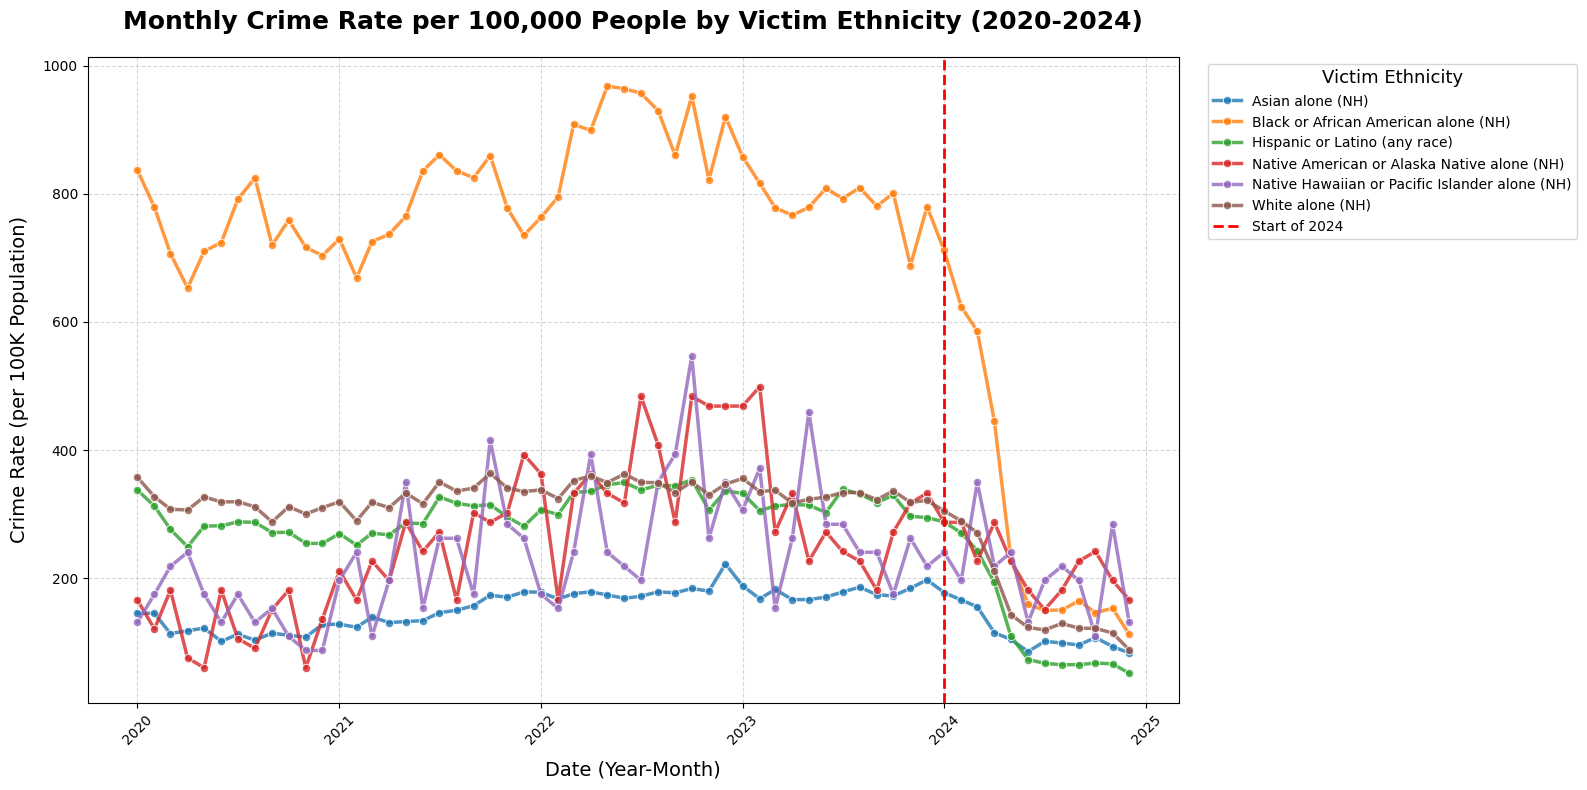

In [25]:

plot_df = main_df.copy()
plot_df['Date'] = plot_df['Date_Occured'].dt.to_timestamp()

plt.figure(figsize=(16, 8))
sns.lineplot(data=plot_df, x='Date', y='Rate', hue='Vict Ethnicity', marker='o', linewidth=2.5, alpha=0.8)

plt.title('Monthly Crime Rate per 100,000 People by Victim Ethnicity (2020-2024)', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Date (Year-Month)', fontsize=14, labelpad=10)
plt.ylabel('Crime Rate (per 100K Population)', fontsize=14, labelpad=10)


plt.axvline(pd.to_datetime('2024-01-01'), color='red', linestyle='--', linewidth=2, label='Start of 2024')
plt.xticks(rotation=45)
plt.legend(title='Victim Ethnicity', title_fontsize='13', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

In [26]:

chi2_crime_analysis = crime[['DR_NO','Date_Occured','Vict Age','Vict Sex','Violent']].copy()
chi2_crime_analysis = chi2_crime_analysis[(chi2_crime_analysis['Vict Age'] > 0) & (chi2_crime_analysis['Vict Sex'].isin(['M', 'F']))]
chi2_crime_analysis['Violent'] = chi2_crime_analysis['Violent'].astype(int)
chi2_before = chi2_crime_analysis[(chi2_crime_analysis['Vict Age'] > 0) & (chi2_crime_analysis['Vict Sex'].isin(['M', 'F'])) & (chi2_crime_analysis['Date_Occured'].dt.year < 2024)].copy()
chi2_after = chi2_crime_analysis[(chi2_crime_analysis['Vict Age'] > 0) & (chi2_crime_analysis['Vict Sex'].isin(['M', 'F'])) & (chi2_crime_analysis['Date_Occured'].dt.year == 2024)].copy()



def run_overall_test(df):
    cont = pd.crosstab(df['Vict Sex'], df['Violent'])
    chi2_stat, p_val, dof, ex = stats.chi2_contingency(cont)
    return p_val

p_val_before = run_overall_test(chi2_before)
p_val_after = run_overall_test(chi2_after)

reject_overall, p_corr_overall, _, _ = multipletests([p_val_before, p_val_after], alpha=0.05, method='fdr_bh')

print(f"Before 2024 - Raw p-value: {p_val_before:.4e} | Corrected: {p_corr_overall[0]:.4e} | Significant: {reject_overall[0]}")
print(f"Year 2024   - Raw p-value: {p_val_after:.4e} | Corrected: {p_corr_overall[1]:.4e} | Significant: {reject_overall[1]}\n")

Before 2024 - Raw p-value: 2.3292e-68 | Corrected: 4.6585e-68 | Significant: True
Year 2024   - Raw p-value: 3.8170e-09 | Corrected: 3.8170e-09 | Significant: True



In [27]:
bins = [0, 17, 25, 35, 50, 64, 150]
labels = ['<18', '18-25', '26-35', '36-50', '51-64', '65+']

chi2_before['Age Group'] = pd.cut(chi2_before['Vict Age'], bins=bins, labels=labels, right=True)
chi2_after['Age Group'] = pd.cut(chi2_after['Vict Age'], bins=bins, labels=labels, right=True)

In [28]:
results = []

def process_age_groups(df, period_name):
    for group in labels:
        group_data = df[df['Age Group'] == group]
        contingency = pd.crosstab(group_data['Vict Sex'], group_data['Violent'])

        if contingency.shape == (2, 2):
            chi2_stat, p_val, dof, ex = stats.chi2_contingency(contingency)
            row_percentages = contingency.div(contingency.sum(axis=1), axis=0)

            prob_m_violent = row_percentages.loc['M', 1] * 100
            prob_f_violent = row_percentages.loc['F', 1] * 100

            higher_risk = 'Male' if prob_m_violent > prob_f_violent else ('Female' if prob_f_violent > prob_m_violent else 'Equal')
        else:
            p_val, prob_m_violent, prob_f_violent, higher_risk = np.nan, np.nan, np.nan, 'N/A'

        results.append({
            'Period': period_name,
            'Age Group': group,
            'Male Violent (%)': prob_m_violent,
            'Female Violent (%)': prob_f_violent,
            'Higher Risk': higher_risk,
            'Raw p-value': p_val
        })

process_age_groups(chi2_before, 'Before 2024')
process_age_groups(chi2_after, '2024')

results_df = pd.DataFrame(results)
valid_tests = results_df.dropna(subset=['Raw p-value']).copy()



reject_bh, pvals_corrected_bh, _, _ = multipletests(valid_tests['Raw p-value'], alpha=0.05, method='fdr_bh')
valid_tests['Corrected p-value (BH)'] = pvals_corrected_bh
valid_tests['Significant (BH)'] = reject_bh

reject_bonf, pvals_corrected_bonf, _, _ = multipletests(valid_tests['Raw p-value'], alpha=0.05, method='bonferroni')
valid_tests['Corrected p-value (Bonf)'] = pvals_corrected_bonf
valid_tests['Significant (Bonf)'] = reject_bonf


In [29]:
valid_tests_pre2024 = valid_tests[valid_tests['Period']!='2024']
valid_tests_pre2024[['Age Group','Higher Risk','Raw p-value','Corrected p-value (BH)','Significant (BH)','Corrected p-value (Bonf)','Significant (Bonf)']]

,Age Group,Higher Risk,Raw p-value,Corrected p-value (BH),Significant (BH),Corrected p-value (Bonf),Significant (Bonf)
0,<18,Female,4.207148e-14,1.262144e-13,True,5.048577e-13,True
1,18-25,Female,1.918475e-27,1.151085e-26,True,2.302170e-26,True
2,26-35,Female,2.613593e-11,5.227185e-11,True,3.136311e-10,True
3,36-50,Female,1.251742e-19,5.006969e-19,True,1.502091e-18,True
4,51-64,Male,6.623321e-14,1.589597e-13,True,7.947985e-13,True
5,65+,Male,3.346686e-29,4.016023e-28,True,4.016023e-28,True


In [30]:
valid_tests_post2024 = valid_tests[valid_tests['Period']=='2024']
valid_tests_post2024[['Age Group','Higher Risk','Raw p-value','Corrected p-value (BH)','Significant (BH)','Corrected p-value (Bonf)','Significant (Bonf)']]

,Age Group,Higher Risk,Raw p-value,Corrected p-value (BH),Significant (BH),Corrected p-value (Bonf),Significant (Bonf)
6,<18,Female,0.261298,0.261298,False,1.000000,False
7,18-25,Female,0.005011,0.006013,True,0.060130,False
8,26-35,Female,0.000188,0.000282,True,0.002258,True
9,36-50,Female,0.000001,0.000002,True,0.000014,True
10,51-64,Male,0.002324,0.003099,True,0.027891,True
11,65+,Male,0.076749,0.083726,False,0.920989,False


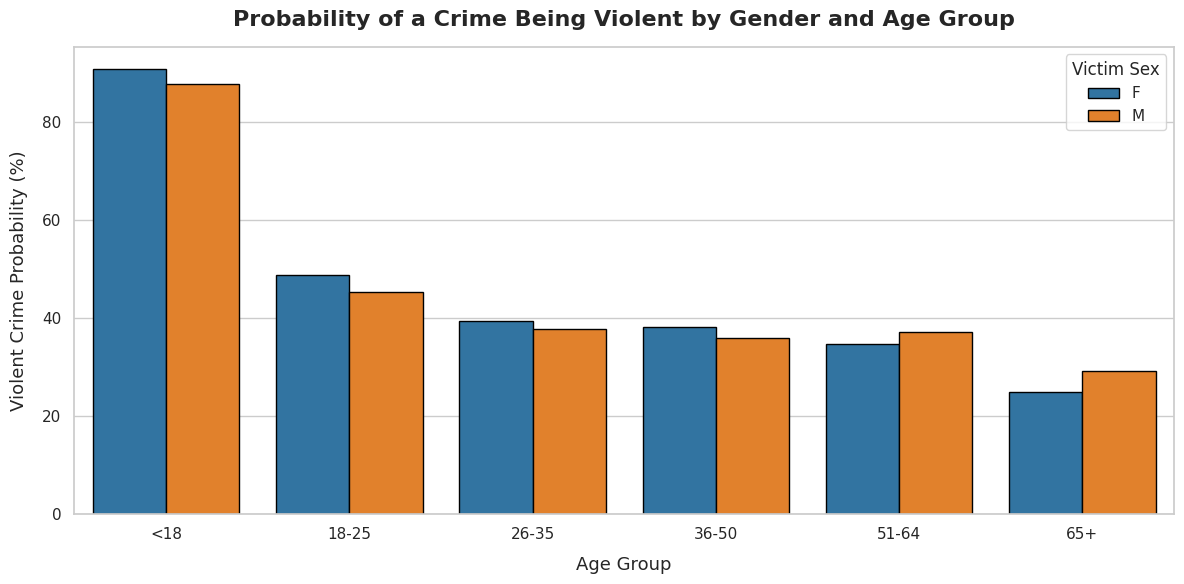

In [31]:

chi2_crime_analysis['Age Group'] = pd.cut(chi2_crime_analysis['Vict Age'], bins=bins, labels=labels, right=True)
plot_data = chi2_crime_analysis.groupby(['Age Group', 'Vict Sex'], observed=True)['Violent'].mean().reset_index()
plot_data['Violent Percentage'] = plot_data['Violent'] * 100

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

sns.barplot(
    data=plot_data,
    x="Age Group",
    y="Violent Percentage",
    hue="Vict Sex",
    hue_order=['F', 'M'],
    palette={'F': '#1f77b4', 'M': '#ff7f0e'},
    edgecolor='black'
)


plt.title('Probability of a Crime Being Violent by Gender and Age Group', fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Age Group", fontsize=13, labelpad=10)
plt.ylabel("Violent Crime Probability (%)", fontsize=13, labelpad=10)
plt.legend(title='Victim Sex', loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()